In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Graficas de barras simples para variables categoricas

Ahora trabajaremos con las variables categóricas y las gráficas de barras simples nos ayudaran a realizar una exploración de los datos

### Ejemplo

In [2]:
df = pd.read_csv('./prestamos.csv')
df

,estado,nivel
0,Totalmente pagada,B
1,Cancelada (impago),C
2,Totalmente pagada,C
3,Totalmente pagada,C
4,Actual,B
...,...,...
450956,Actual,D
450957,Actual,D
450958,Actual,D
450959,Actual,D


Se debe de saber los niveles

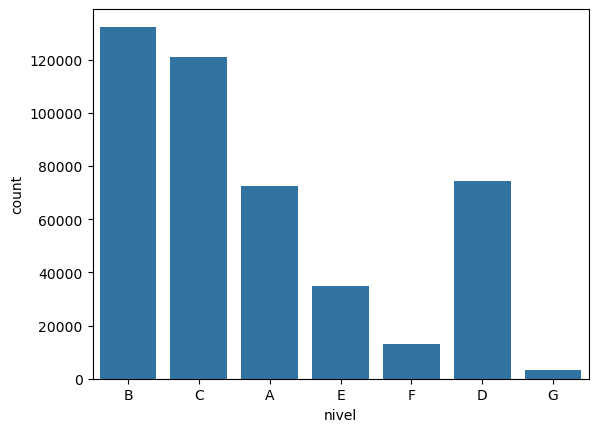

In [3]:
#funcion countplot
ax = sns.countplot(df, x='nivel')

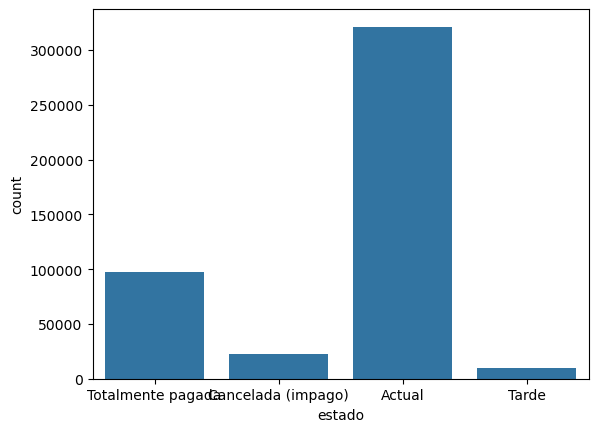

In [4]:
ax = sns.countplot(df, x='estado')

Ayuda a ver las categorías y también a identificar los datos erroneos, es más facil equivocarse con variables categoricas que con las numericas

En ocasiones conviene representar los resultados en porcentaje

In [5]:
sns.__version__

'0.13.2'

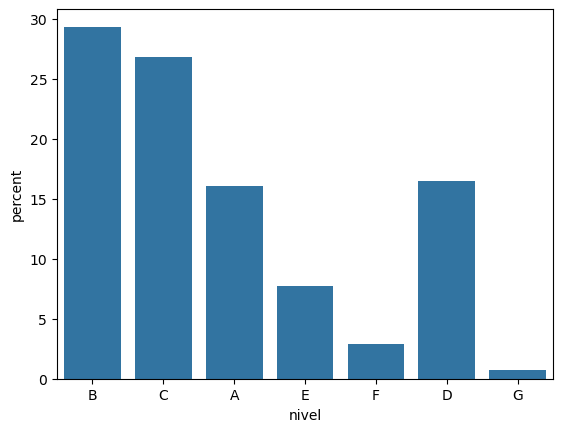

In [6]:
#Nota: el argumento stat solo corre de las versiones 11 en adelante
ax = sns.countplot(df, x='nivel', stat='percent')

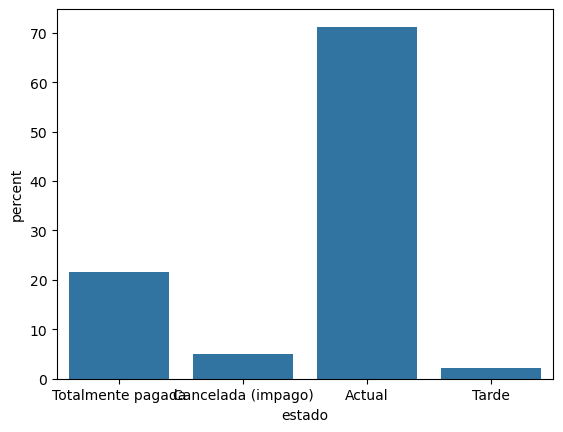

In [7]:
ax = sns.countplot(df, x='estado', stat='percent')

### Opciones adicionales de visualización de los datos categóricos

In [8]:
df['nivel'].value_counts()

nivel
B    132370
C    120875
D     74277
A     72490
E     34804
F     12904
G      3241
Name: count, dtype: int64

#### Barras ordenadas de manera descendente

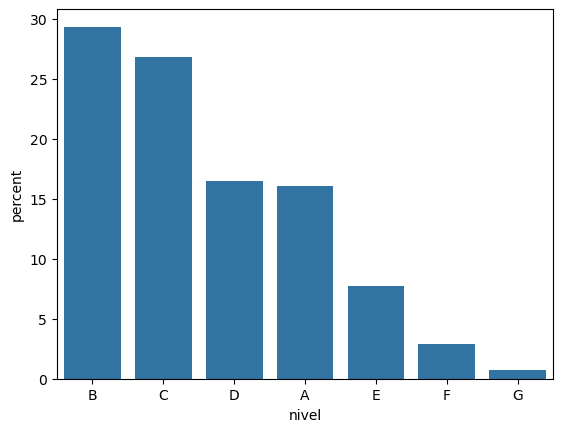

In [9]:
#1. Obtener los indices
index = df['nivel'].value_counts().index
#2. Dar los indices
ax = sns.countplot(df, x='nivel', order = index, stat='percent')

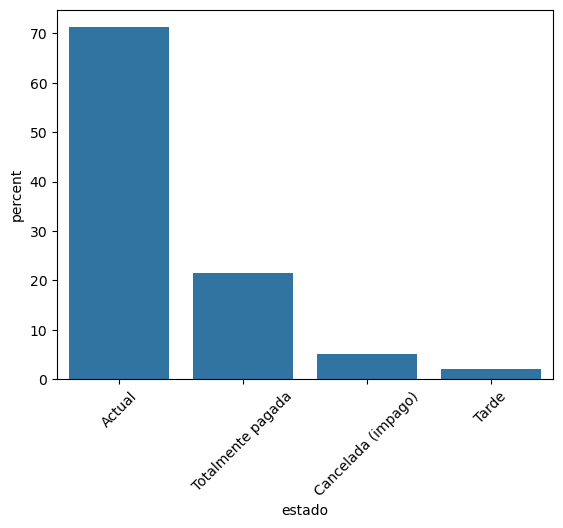

In [10]:
index = df['estado'].value_counts().index
ax = sns.countplot(df, x='estado', order = index, stat = 'percent')
#Con esto rotamos las etiquetas del eje x
ax.tick_params(axis='x', rotation=45)

#### Gráfica en forma horizontal

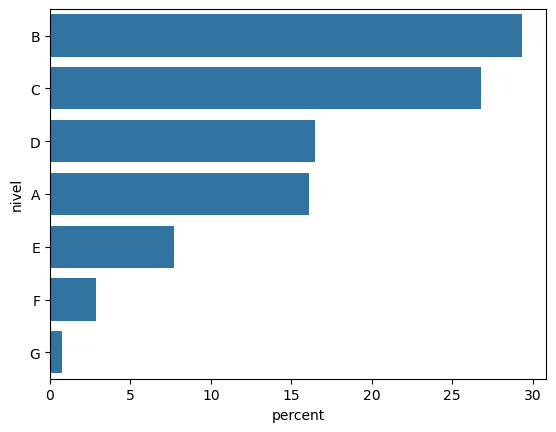

In [11]:
index = df['nivel'].value_counts().index
ax = sns.countplot(df, y='nivel', order = index, stat = 'percent')

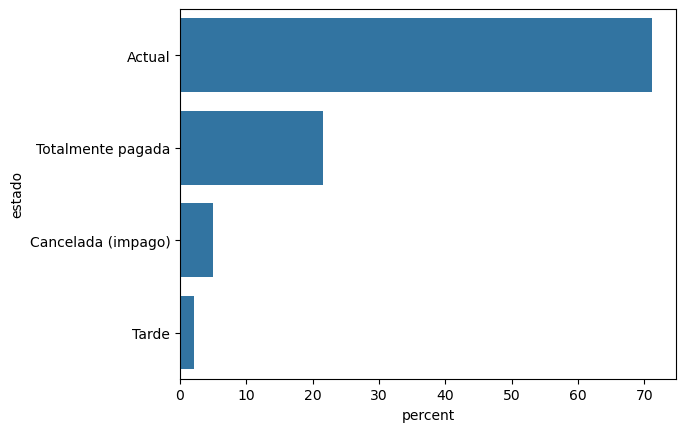

In [12]:
index = df['estado'].value_counts().index
ax = sns.countplot(df, y='estado', order = index, stat = 'percent')

Observaciones:
- Aproximadamente un 5% de los créditos no se pueden recuperar (estado = Cancelada (impago))
- El 3% restante están activos pero los deudores no los han pagado a tiempo (estado = Tarde)
- Casi el 70% de los créditos se encuentran activos actualmente (estado = Actual)
- Un poco más del 20% de los créditos ya ha sido pagado (estado = Totalmente pagada)

## Limpieza de datos

### Problema

Se necesita encontrar a los clientes que quieran aceptar un certificado de deposito, para que después se puedan contactar por vía telefónica.

¿Qué perfil tienen los clientes con mayor potencial para el certificado de deposito?

In [13]:
df = pd.read_csv('./banco.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45210,51,technician,married,tertiary,no,825.0,no,no,cellular,17,nov,977.0,3,-1.0,0,unknown,yes
45211,71,retired,divorced,primary,no,1729.0,no,no,cellular,17,nov,456.0,2,-1.0,0,unknown,yes
45212,72,retired,married,secondary,no,5715.0,no,no,cellular,17,nov,1127.0,5,184.0,3,success,yes
45213,57,blue-collar,married,secondary,no,668.0,no,no,telephone,17,nov,508.0,4,-1.0,0,unknown,no


In [14]:
print(df.shape)
df.head()

(45215, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [15]:
df.info()
print('------')
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB
------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entri

Info dice la  información del dataframe, te dice el tipo de dato que manejan las columnas, y la cantidad de tipo que se repite o utiliza. También dice que usa 5.9 mb aprox en la memoria ram. Con memory_usage dice lo que realmente esta gastando la memoria

#### Limpieza

1. Datos faltantes
2. Columnas que no tienen relevancia (no tienen que ver con el problema a resolver)
3. Filas repetidas
4. Variables numéricas, valores atípicos (outliers)
5. Variables categóricas, errores tipográficos

##### Datos faltantes

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


In [17]:
# dropna busca los valores, con el inplace no debemos de hacer df = df.dropna
df.dropna(inplace=True) # elimina las filas con datos faltantes, y la sobreescribimos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  object 
 2   marital    45207 non-null  object 
 3   education  45207 non-null  object 
 4   default    45207 non-null  object 
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  object 
 7   loan       45207 non-null  object 
 8   contact    45207 non-null  object 
 9   day        45207 non-null  int64  
 10  month      45207 non-null  object 
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  object 
 16  y          45207 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 6.2+ MB


##### Columnas irrelevantes

In [18]:
cols_cat = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

#Agarra cada columna, la recorre, se saca el dato, nunique busca los datos unicos y los nombramos como subniveles
for col in cols_cat:
    print(f'Columna {col}: {df[col].nunique()} subniveles')

Columna job: 18 subniveles
Columna marital: 6 subniveles
Columna education: 10 subniveles
Columna default: 2 subniveles
Columna housing: 2 subniveles
Columna loan: 6 subniveles
Columna contact: 5 subniveles
Columna month: 12 subniveles
Columna poutcome: 6 subniveles
Columna y: 2 subniveles


Todas las columnas categóricas tienen más de 1 subnivel. No eliminaremos ninguna. Verifiquemos lo que ocurre con las columnas numéricas:

In [19]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000
mean,41.005596,1374.201318,15.806534,258.032539,2.763731,40.178225,0.580198
std,12.037399,3924.491665,8.323015,257.460759,3.098058,100.103283,2.303341
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Todas las columnas numericas tienen desviaciones estandar ('std') diferentes de cero, lo que indica que no tienen un único valor (si valiera cero todo esta en el centro y sería un mismo valor). Preservamos todas las columnas numéricas

##### Filas repetidas

In [20]:
print(f'Tamaño del set antes de eliminar las filas repetidas: {df.shape}')
df.drop_duplicates(inplace = True)
print(f'Tamaño del set después de eliminar las filas repetidas: {df.shape}')


Tamaño del set antes de eliminar las filas repetidas: (45207, 17)
Tamaño del set después de eliminar las filas repetidas: (45203, 17)


In [21]:
def calcular_iqr(data):
    #Calcular cuartiles 1 y 3
    qs = data.quantile([0.25, 0.75])

    #Calcular IQR
    iqr = qs[0.75] - qs[0.25]
    return iqr, qs[0.25], qs[0.75]

##### Valores atípicos en variables númericas

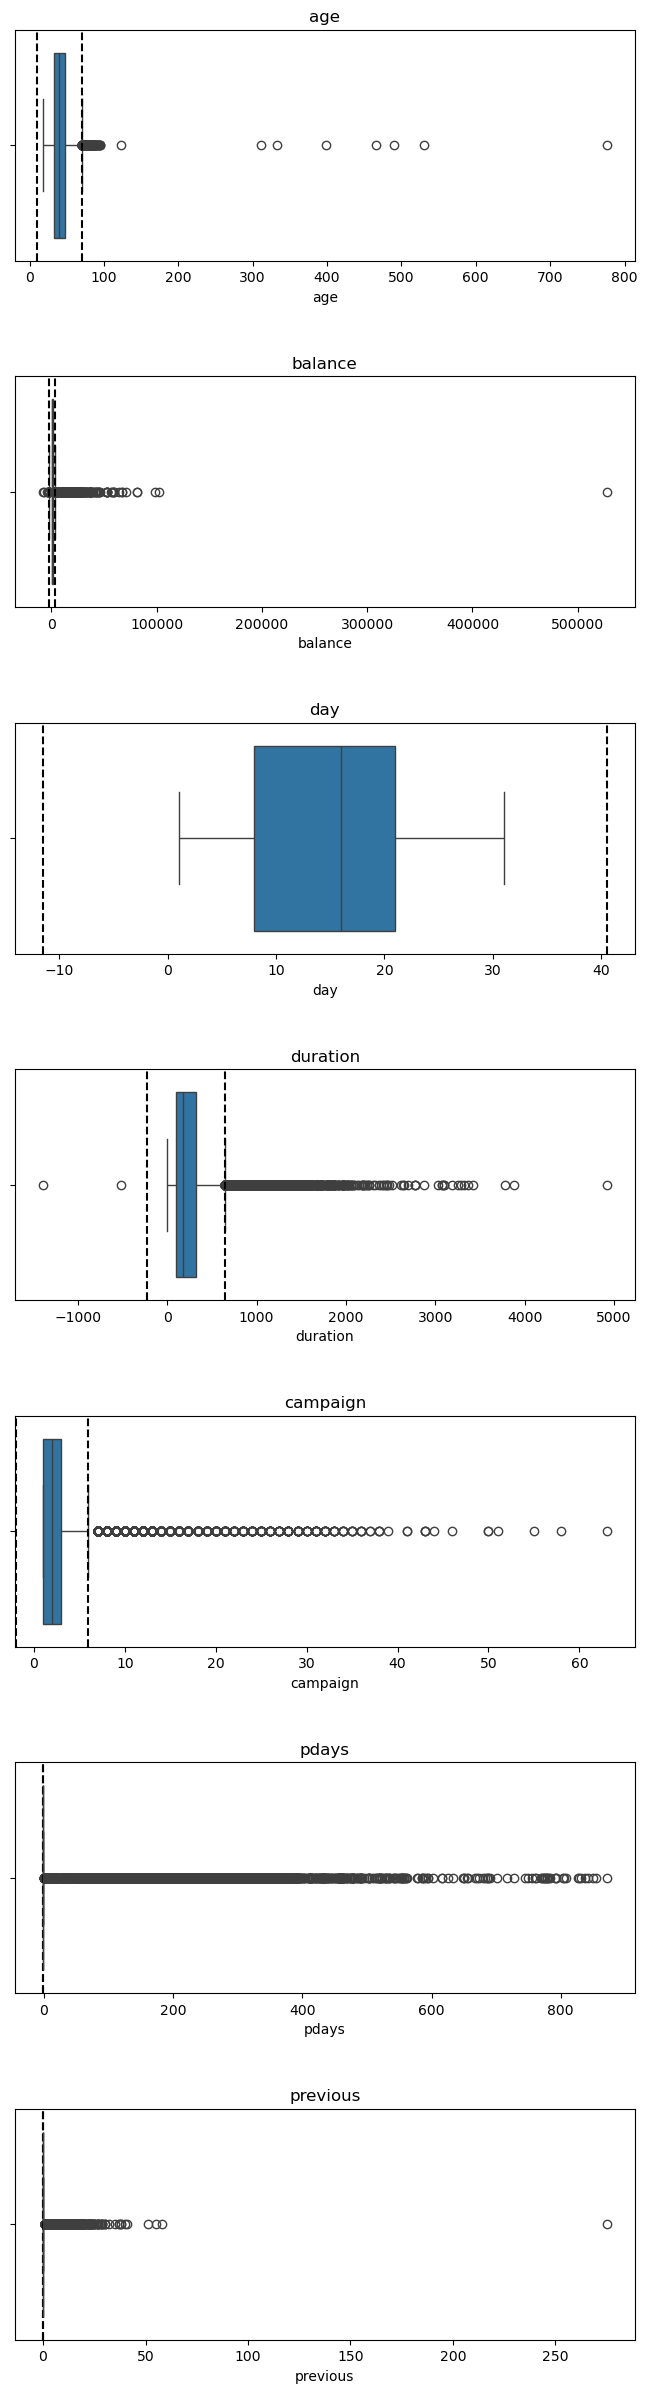

In [22]:
cols_num = ['age', 'balance', 'day', 'duration','campaign','pdays', 'previous']

fig, ax = plt.subplots(nrows = 7, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace = 0.5)

for i, col in enumerate(cols_num):
    IQR, Q1, Q3 = calcular_iqr(df[col])
    sns.boxplot(x=col, data = df, ax = ax[i])
    ax[i].axvline((Q1-(1.5*IQR)), color = 'black', linestyle='--')
    ax[i].axvline((Q3+(1.5*IQR)), color = 'black', linestyle='--')
    ax[i].set_title(col)

##### Observaciones

- 'age': edades mucho mayores a 100 años
- 'duration': hay valores negativos
- 'previous': extremadamente alto (cercano a 300)

In [23]:
print(f'Tamaño del set antes de eliminar registros de edad: {df.shape}')
df = df[df['age']<=95]
print(f'Tamaño del set despues de eliminar registros de edad: {df.shape}')

Tamaño del set antes de eliminar registros de edad: (45203, 17)
Tamaño del set despues de eliminar registros de edad: (45195, 17)


In [24]:
print(f'Tamaño del set antes de eliminar registros de duración: {df.shape}')
df = df[df['duration']>0]
print(f'Tamaño del set despues de eliminar registros de duración: {df.shape}')

Tamaño del set antes de eliminar registros de duración: (45195, 17)
Tamaño del set despues de eliminar registros de duración: (45190, 17)


In [25]:
print(f'Tamaño del set antes de eliminar registros de previous: {df.shape}')
df = df[df['previous']<=100]
print(f'Tamaño del set despues de eliminar registros de previous: {df.shape}')

Tamaño del set antes de eliminar registros de previous: (45190, 17)
Tamaño del set despues de eliminar registros de previous: (45189, 17)


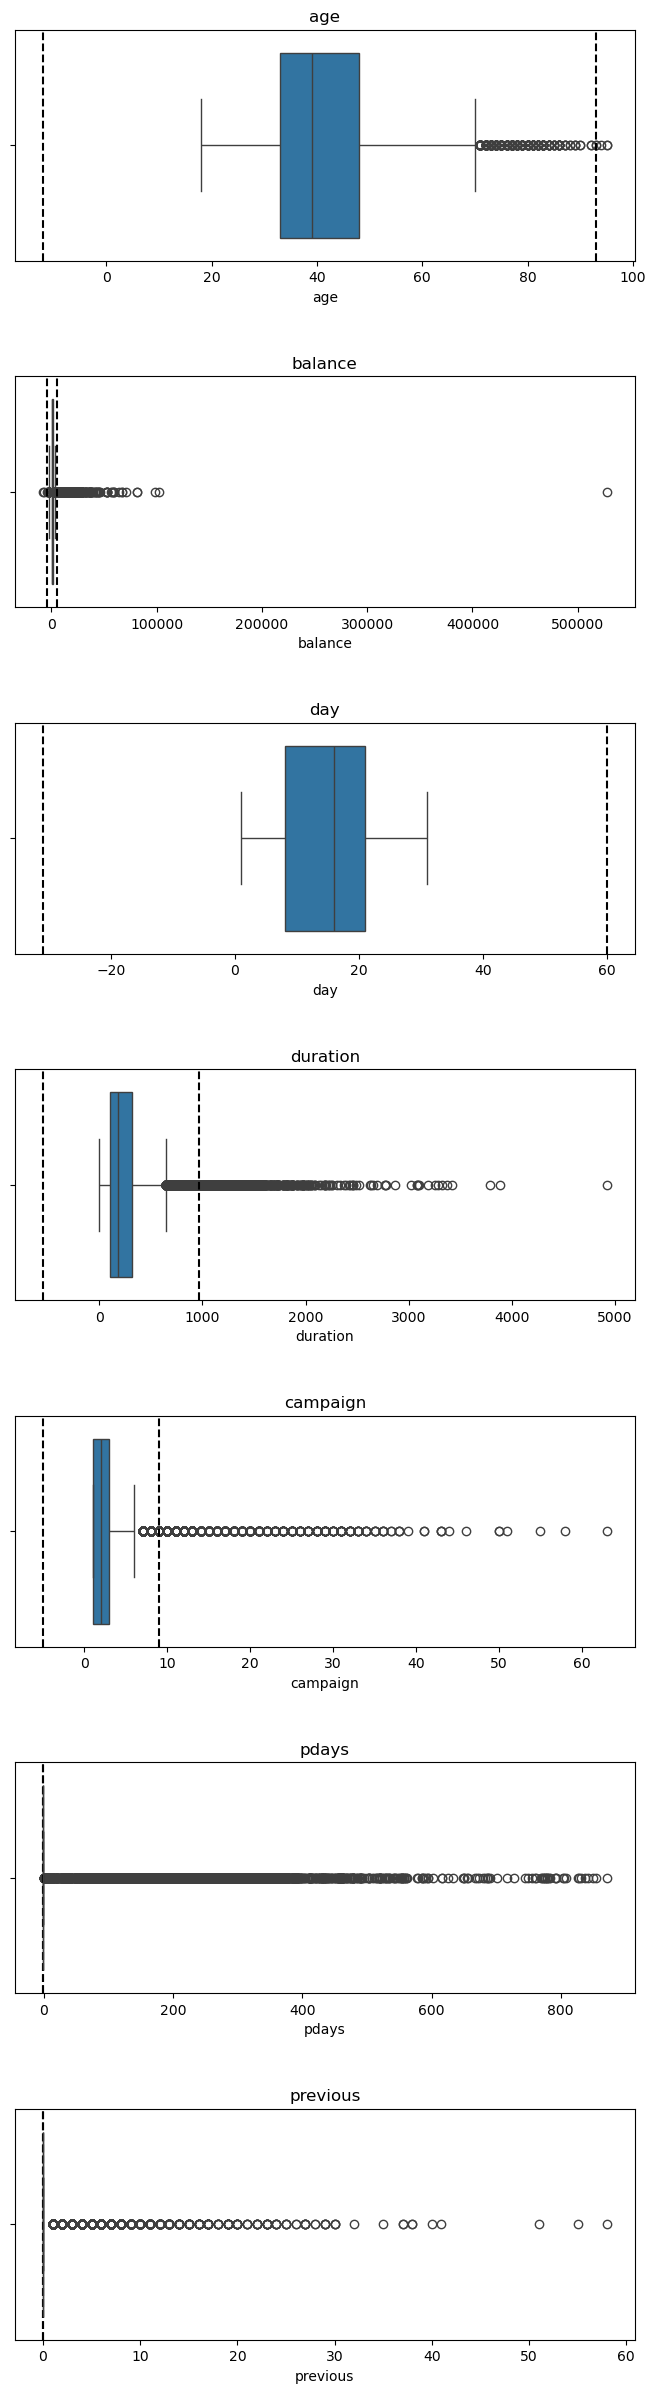

In [26]:
cols_num = ['age', 'balance', 'day', 'duration','campaign','pdays', 'previous']

fig, ax = plt.subplots(nrows = 7, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace = 0.5)

for i, col in enumerate(cols_num):
    IQR, Q1, Q3 = calcular_iqr(df[col])
    sns.boxplot(x=col, data = df, ax = ax[i])
    ax[i].axvline((Q1-(3*IQR)), color = 'black', linestyle='--')
    ax[i].axvline((Q3+(3*IQR)), color = 'black', linestyle='--')
    ax[i].set_title(col)

##### Errores tipograficos

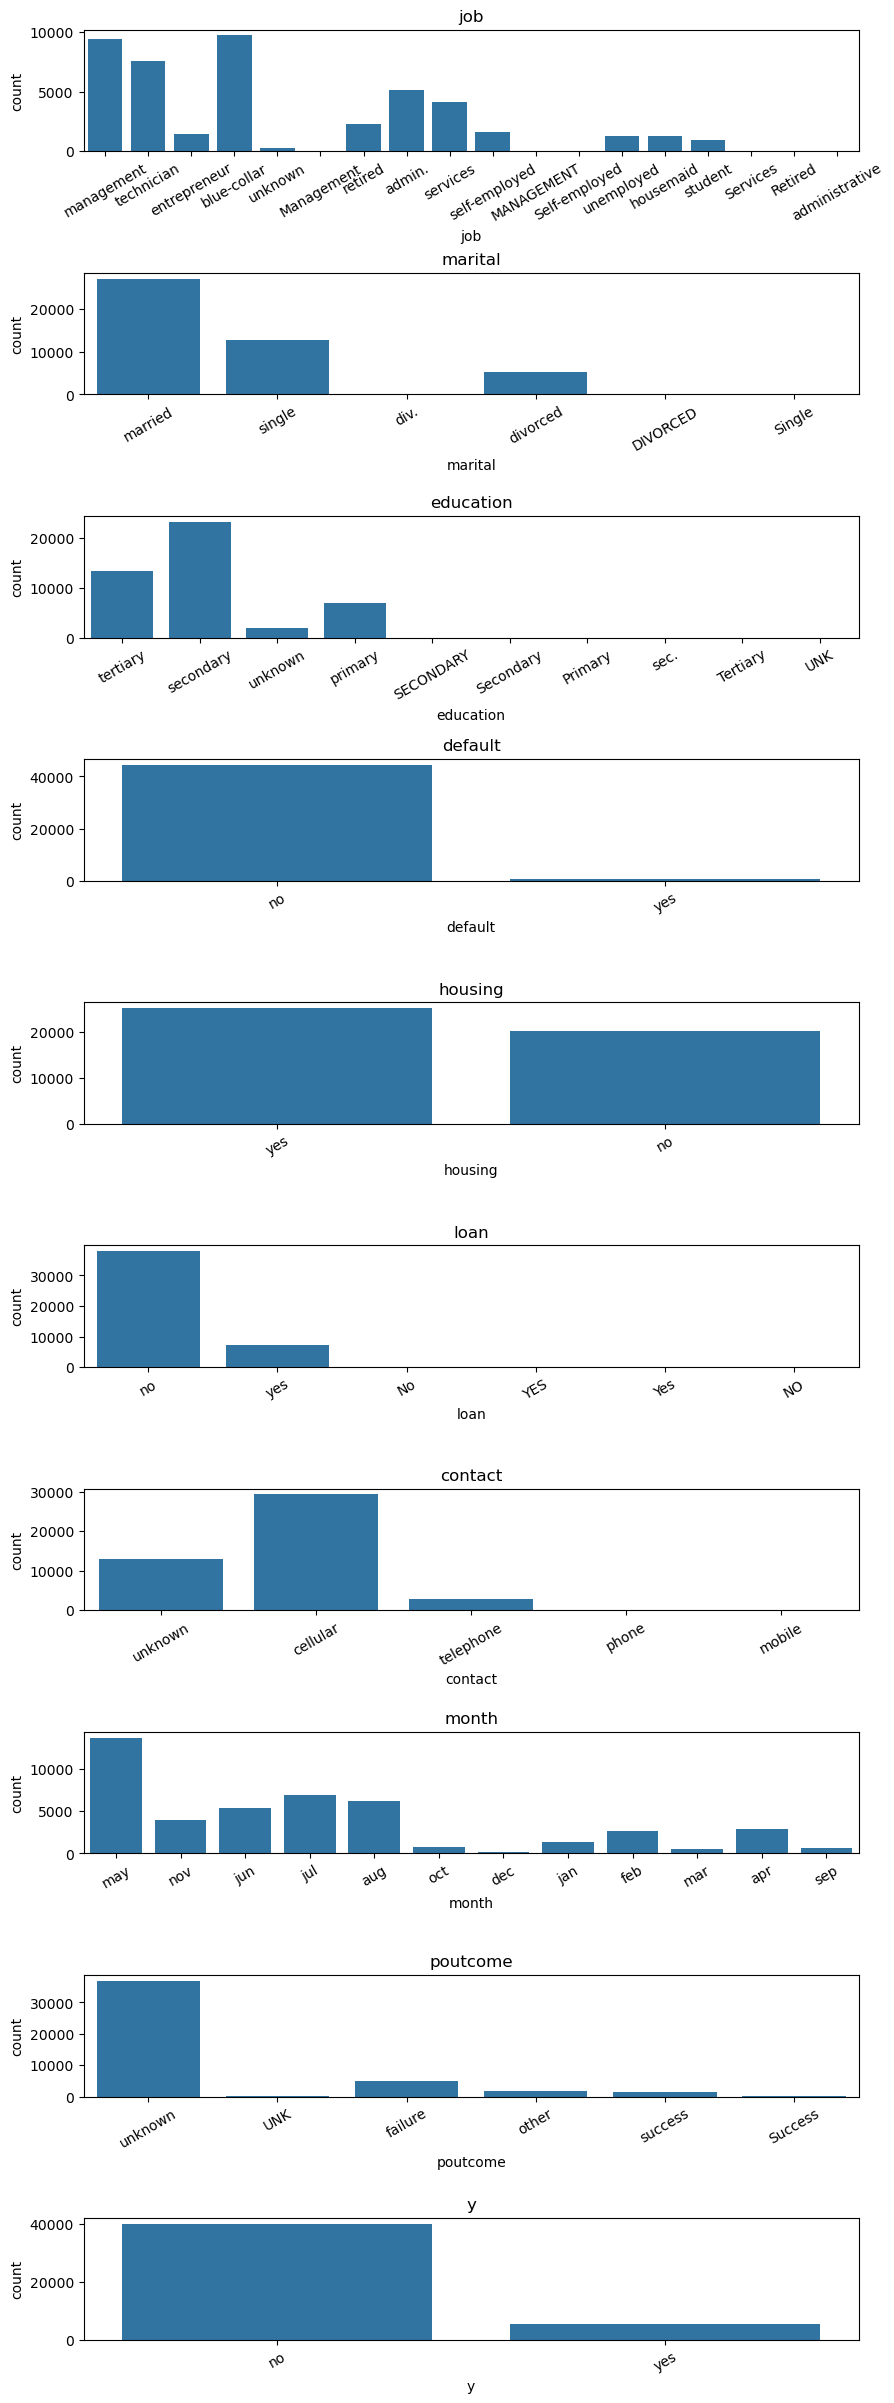

In [27]:
cols_cat = ['job', 'marital', 'education', 'default','housing','loan', 'contact', 'month', 'poutcome', 'y']

fig, ax = plt.subplots(nrows = 10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace = 1)

for i, col in enumerate(cols_cat):
    sns.countplot(x=col, data = df, ax = ax[i])
    ax[i].set_title(col)
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)


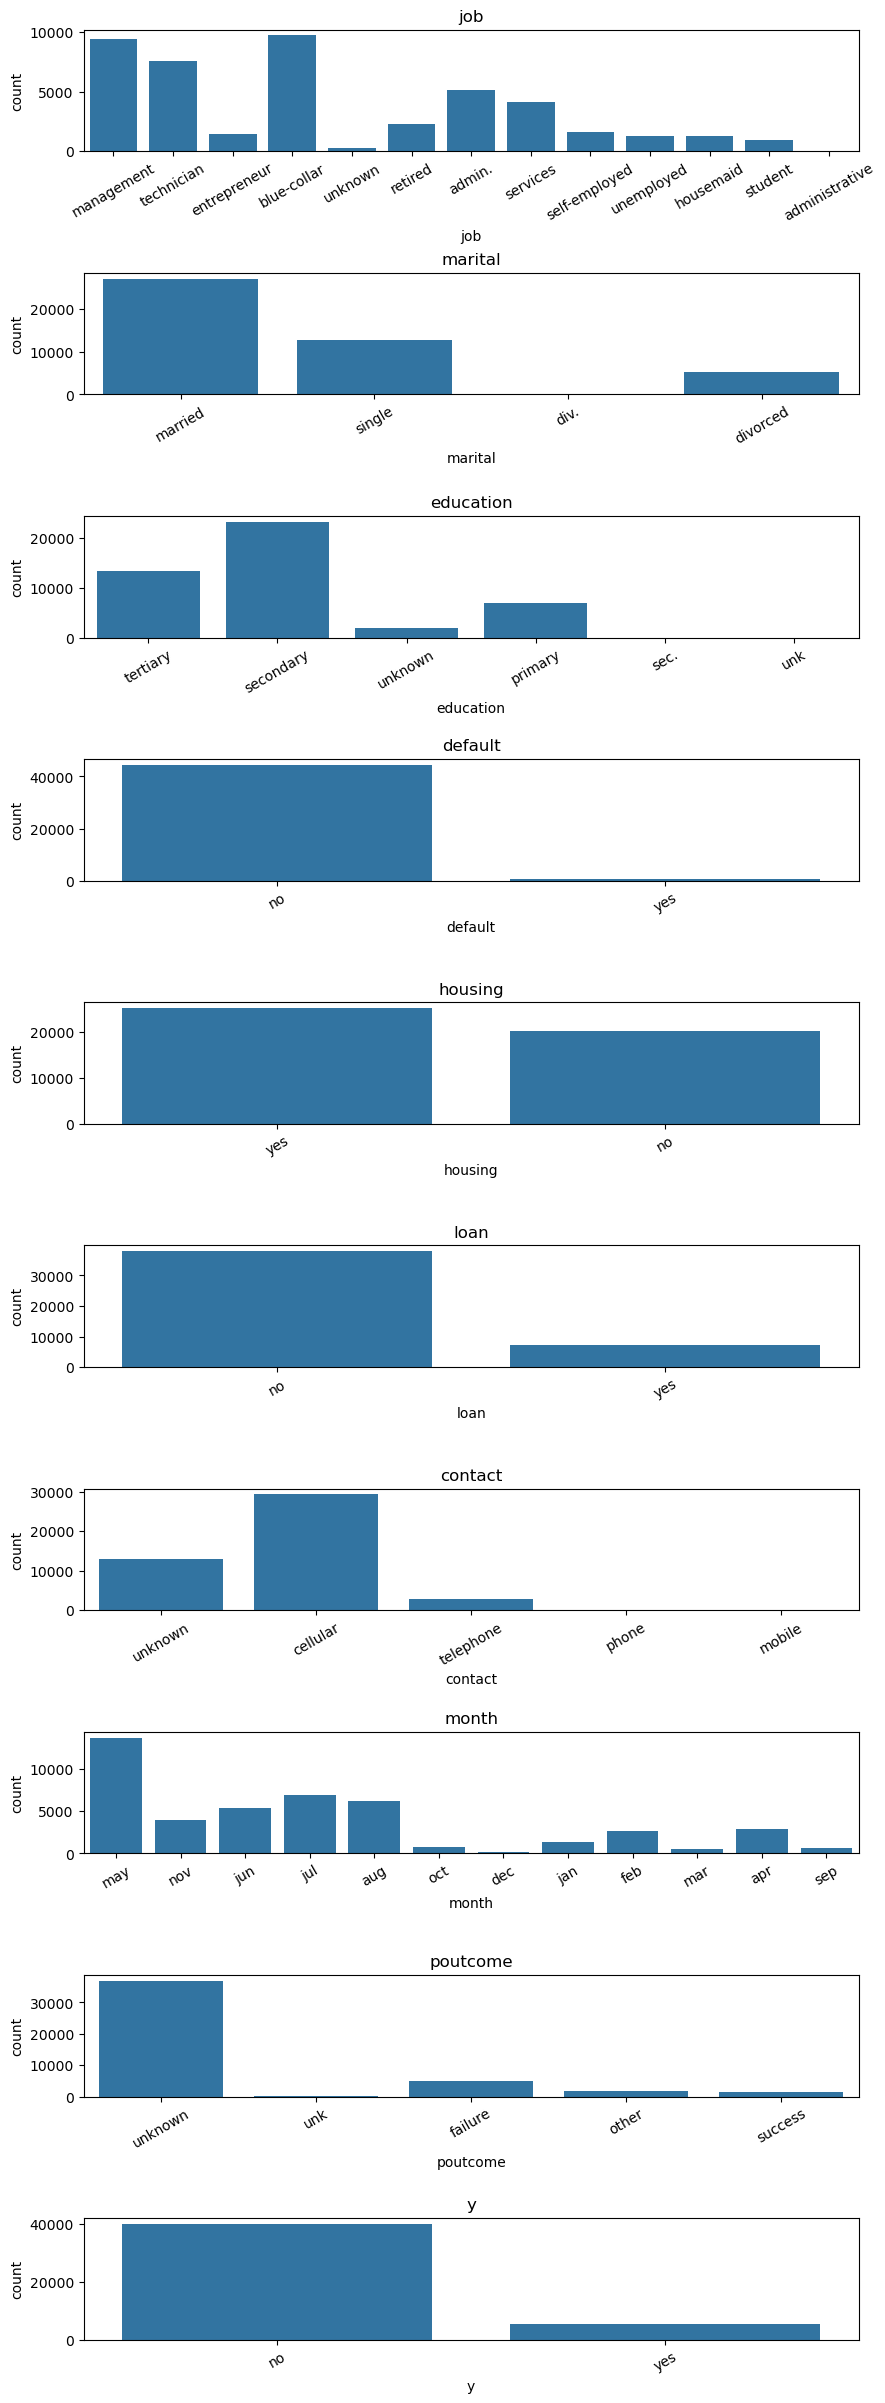

In [28]:
for column in df.columns:
    #Representar en minusculas solo si la columna es categorica
    if column in cols_cat:
        df[column] = df[column].str.lower()

# Y generamos las gráficas nuevamente
fig, ax = plt.subplots(nrows = 10, ncols=1, figsize=(10,30))
fig.subplots_adjust(hspace = 1)

for i, col in enumerate(cols_cat):
    sns.countplot(x=col, data = df, ax = ax[i])
    ax[i].set_title(col)
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=30)

In [29]:
#job: unificar admin y administrative
print(df['job'].unique())
df['job'] = df['job'].str.replace('admin','administrative', regex = False)
print(df['job'].unique())


['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student' 'administrative']
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'administrative.' 'services' 'self-employed' 'unemployed'
 'housemaid' 'student' 'administrativeistrative']


In [30]:
#marital: unificar div y divorced
print(df['marital'].unique())
df['marital'] = df['marital'].str.replace('div.','divorced', regex = False)
print(df['marital'].unique())


['married' 'single' 'div.' 'divorced']
['married' 'single' 'divorced']


In [31]:
#education: unificar sec y secondary, unk y unkown
print(df['education'].unique())
df['education'] = df['education'].str.replace('sec.','secondary', regex = False)
df.loc[df['education']=='unk','education']='unknown'
print(df['education'].unique())


['tertiary' 'secondary' 'unknown' 'primary' 'sec.' 'unk']
['tertiary' 'secondary' 'unknown' 'primary']


In [32]:
#contact: unificar telephone y phone
print(df['contact'].unique())
df.loc[df['contact']=='phone','contact']='telephone'
df.loc[df['contact']=='mobile','contact']='cellular'

print(df['contact'].unique())


['unknown' 'cellular' 'telephone' 'phone' 'mobile']
['unknown' 'cellular' 'telephone']


In [33]:
#poutcome: unificar unk y unknown
print(df['poutcome'].unique())
df.loc[df['poutcome']=='unk','poutcome']='unknown'
print(df['contact'].unique())


['unknown' 'unk' 'failure' 'other' 'success']
['unknown' 'cellular' 'telephone']


In [34]:
df.shape

(45189, 17)

In [35]:
ruta = './dataset_banco_clean.csv'
df.to_csv(ruta, index=False)